**Task 1:**
The dataset was divided into training, validation, and test sets based on folder indices. For each action class, folders 1–16 were used for training, 17–19 for validation, and 20–25 for testing.

In [ ]:
import os
import shutil

# Path to original dataset
base_dir = "/content/drive/MyDrive/Colab Notebooks/UCF11_updated_mpg"

# Path where we want to save the split dataset
output_dir = "/content/drive/MyDrive/Colab Notebooks/UCF11_split"

# Define train / val / test folders
train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

# Create these folders if they don’t exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Loop over each class (e.g., biking, diving, ...)
for cls in os.listdir(base_dir):

    # Skip the Annotation folder
    if cls.lower() == "annotation":
        continue
    cls_path = os.path.join(base_dir, cls)

    # Make sure it's actually a folder
    if not os.path.isdir(cls_path):
        continue
    print("Processing:", cls)

    # Create class folders inside train/val/test
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # Loop through folders like v_biking_01, v_biking_02, ...
    for folder in sorted(os.listdir(cls_path)):

        # Only process folders that start with 'v_'
        if not folder.startswith("v_"):
            continue
        src = os.path.join(cls_path, folder)

        # Skip if not a folder
        if not os.path.isdir(src):
            continue

        # Get the folder number (e.g., 01, 02, ..., 25)
        idx = int(folder.split("_")[-1])

        # Decide where to copy based on index
        if idx <= 16:
            dst = os.path.join(train_dir, cls, folder)
        elif idx <= 19:
            dst = os.path.join(val_dir, cls, folder)
        else:
            dst = os.path.join(test_dir, cls, folder)

        # Copy the folder (videos inside will be copied too)
        shutil.copytree(src, dst, dirs_exist_ok=True)

Processing: basketball
Processing: biking
Processing: diving
Processing: golf_swing
Processing: horse_riding
Processing: soccer_juggling
Processing: trampoline_jumping
Processing: tennis_swing
Processing: volleyball_spiking
Processing: swing
Processing: walking


**Task2**: This code implements a 2D CNN-based video classification pipeline. It first loads videos from the dataset and randomly samples a few frames from each video. Each frame is resized, normalized, and used as an input image for training. A pretrained ResNet18 model is used, with its final layer modified to match the number of action classes. The model is trained using these sampled frames and evaluated on a validation set. This approach treats each frame independently and learns spatial features for action classification.

100%|██████████| 32/32 [00:12<00:00,  2.52it/s]



Evaluating with 1 frames...
Accuracy (1 frames): 0.7414

Evaluating with 5 frames...
Accuracy (5 frames): 0.7833

Evaluating with 10 frames...
Accuracy (10 frames): 0.7857

================= RESULTS TABLE =================
Frames per Video | Test Accuracy
---------------------------------
        1         | 0.7414
        5         | 0.7833
       10         | 0.7857


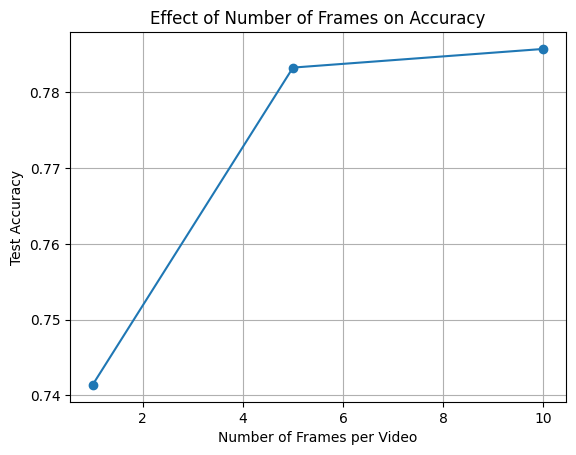

In [ ]:
!pip install opencv-python

import os
import cv2
import torch
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

BASE_PATH = "/content/drive/MyDrive/Colab Notebooks/UCF11_split"
train_path = os.path.join(BASE_PATH, "train")
val_path   = os.path.join(BASE_PATH, "val")
test_path  = os.path.join(BASE_PATH, "test")

#Frame sampling
def sample_random_frames(video_path, num_frames=5, size=112):
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frames = []

    if total_frames <= 0:
        return frames

    indices = sorted(random.sample(range(total_frames),
                                   min(num_frames, total_frames)))

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()

        if ret:
            frame = cv2.resize(frame, (size, size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame)

    cap.release()
    return frames

# Dataset
class UCF11FrameDataset(Dataset):
    def __init__(self, root_dir, transform=None, frames_per_video=3):
        self.samples = []
        self.transform = transform
        self.frames_per_video = frames_per_video

        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)

            for folder in os.listdir(cls_path):
                folder_path = os.path.join(cls_path, folder)

                for file in os.listdir(folder_path):
                    if file.endswith(".mpg"):
                        video_path = os.path.join(folder_path, file)
                        self.samples.append((video_path, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        video_path, label = self.samples[idx]

        frames = sample_random_frames(video_path, self.frames_per_video)

        # FIX: handle empty frames
        if len(frames) == 0:
            frame = np.zeros((112,112,3), dtype=np.uint8)
        else:
            frame = random.choice(frames)

        if self.transform:
            frame = self.transform(frame)

        return frame, label

# Transforms
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((112,112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# data loaders
train_dataset = UCF11FrameDataset(train_path, transform, frames_per_video=3)
val_dataset   = UCF11FrameDataset(val_path, transform, frames_per_video=3)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
num_classes = len(train_dataset.classes)

# model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# Train setup
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Train function
def train(model, loader):
    model.train()
    total_loss = 0

    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Validation function
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


# Train loop
for epoch in range(5):
    loss = train(model, train_loader)
    val_acc = evaluate(model, val_loader)
    #print(f"Epoch {epoch+1}: Loss={loss:.4f}, Val Acc={val_acc:.4f}")

# Video prediction
def predict_video(model, video_path, num_frames=10):
    frames = sample_random_frames(video_path, num_frames)

    # skip bad videos safely
    if len(frames) == 0:
        return None
    preds = []
    for frame in frames:
        frame = transform(frame).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(frame)
            prob = torch.softmax(output, dim=1)
            preds.append(prob.cpu().numpy())

    avg_pred = np.mean(preds, axis=0)

    return np.argmax(avg_pred)

# Video-level evaluation
def evaluate_video_level(model, root_dir, num_frames=10):
    correct = 0
    total = 0

    classes = sorted(os.listdir(root_dir))
    class_to_idx = {cls: i for i, cls in enumerate(classes)}

    for cls in classes:
        cls_path = os.path.join(root_dir, cls)

        for folder in os.listdir(cls_path):
            folder_path = os.path.join(cls_path, folder)

            for file in os.listdir(folder_path):
                if file.endswith(".mpg"):
                    video_path = os.path.join(folder_path, file)

                    pred = predict_video(model, video_path, num_frames)

                    # skip failed videos
                    if pred is None:
                        continue

                    label = class_to_idx[cls]

                    if pred == label:
                        correct += 1

                    total += 1

    return correct / total

# Different frame numbers
frame_settings = [1, 5, 10]
results = []
for nf in frame_settings:
    print(f"\nEvaluating with {nf} frames...")

    acc = evaluate_video_level(model, test_path, num_frames=nf)

    print(f"Accuracy ({nf} frames): {acc:.4f}")

    results.append((nf, acc))

# Print table
print("\n================= RESULTS TABLE =================")
print("Frames per Video | Test Accuracy")
print("---------------------------------")
for nf, acc in results:
    print(f"{nf:^17} | {acc:.4f}")

# Plot
frames = [r[0] for r in results]
accuracies = [r[1] for r in results]
plt.figure()
plt.plot(frames, accuracies, marker='o')
plt.xlabel("Number of Frames per Video")
plt.ylabel("Test Accuracy")
plt.title("Effect of Number of Frames on Accuracy")
plt.grid(True)
plt.show()

**Task 3:**
This code uses a 3D CNN (R3D-18) to classify videos by learning from consecutive frames (clips) instead of single images.
The model captures both spatial and temporal information, trains on video clips, and is evaluated using video-level predictions.

In [ ]:
import os
import cv2
import torch
import random
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models.video as video_models


BASE = "/content/drive/MyDrive/Colab Notebooks/UCF11_split"
train_path = os.path.join(BASE, "train")
val_path   = os.path.join(BASE, "val")
test_path  = os.path.join(BASE, "test")

# Sample a clip
def get_clip(video, clip_len=8, size=112):
    """
    Extract a short clip (sequence of frames) from a video
    """
    cap = cv2.VideoCapture(video)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Skip short videos
    if total < clip_len:
        cap.release()
        return None

    # Random starting point
    start = random.randint(0, total - clip_len)
    frames = []
    for i in range(start, start + clip_len):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, f = cap.read()

        if not ok:
            cap.release()
            return None
        # Resize and convert color
        f = cv2.resize(f, (size, size))
        f = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        frames.append(f)
    cap.release()
    return np.array(frames)   # shape: (T, H, W, C)


# Dataset
class UCFVideoDataset(Dataset):
    """
    Dataset that returns a video clip + label
    """
    def __init__(self, root, tfm, clip_len=8):
        self.data = []
        self.tfm = tfm
        self.clip_len = clip_len
        classes = sorted(os.listdir(root))
        self.c2i = {c:i for i,c in enumerate(classes)}
        # Collect all video paths
        for c in classes:
            for folder in os.listdir(os.path.join(root, c)):
                p = os.path.join(root, c, folder)
                for f in os.listdir(p):
                    if f.endswith(".mpg"):
                        self.data.append((os.path.join(p,f), self.c2i[c]))
    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        path, label = self.data[i]

        clip = get_clip(path, self.clip_len)
        # If failed → use empty clip
        if clip is None:
            clip = np.zeros((self.clip_len,112,112,3), dtype=np.uint8)
        # Apply transform to each frame
        clip = [self.tfm(f) for f in clip]
        # Convert to tensor: (C, T, H, W)
        clip = torch.stack(clip).permute(1,0,2,3)
        return clip, label
# Transform
tfm = T.Compose([
    T.ToPILImage(),
    T.Resize((112,112)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],
                [0.229,0.224,0.225])
])

# Data loader
train_loader = DataLoader(UCFVideoDataset(train_path, tfm), 4, shuffle=True)
val_loader   = DataLoader(UCFVideoDataset(val_path, tfm), 4)
num_classes = len(os.listdir(train_path))

# Model (3D CNN)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pretrained 3D ResNet (video model)
model = video_models.r3d_18(weights="DEFAULT")

# Replace final layer
model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
model.to(device)

# Loss
loss_fn = torch.nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

# Train function
def train_epoch(loader):
    model.train()
    total_loss = 0
    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = loss_fn(out, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation
def eval_epoch(loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)

            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# Train loop
for e in range(5):
    loss = train_epoch(train_loader)
    acc  = eval_epoch(val_loader)
    print(f"Epoch {e+1}: Loss={loss:.4f}, Val Acc={acc:.4f}")
    print("="*40)

# Video-level test
def predict_video(video):
    clip = get_clip(video)

    if clip is None:
        return None

    clip = [tfm(f) for f in clip]
    clip = torch.stack(clip).permute(1,0,2,3).unsqueeze(0).to(device)

    with torch.no_grad():
        out = model(clip)

    return torch.argmax(out, 1).item()

def test_video_level(root):
    correct = total = 0
    classes = sorted(os.listdir(root))
    c2i = {c:i for i,c in enumerate(classes)}

    for c in classes:
        for folder in os.listdir(os.path.join(root,c)):
            p = os.path.join(root,c,folder)

            for f in os.listdir(p):
                if f.endswith(".mpg"):
                    pred = predict_video(os.path.join(p,f))
                    if pred is None: continue

                    if pred == c2i[c]:
                        correct += 1
                    total += 1

    return correct / total

# Test of accuracy
test_acc = test_video_level(test_path)
print("="*40)
print("3D CNN Test Accuracy:", 'box',  test_acc)
print("="*40)

100%|██████████| 254/254 [00:29<00:00,  8.55it/s]


Epoch 1: Loss=0.9785, Val Acc=0.9111


100%|██████████| 254/254 [00:29<00:00,  8.57it/s]


Epoch 2: Loss=0.3756, Val Acc=0.8889


100%|██████████| 254/254 [00:29<00:00,  8.61it/s]


Epoch 3: Loss=0.3010, Val Acc=0.8833


100%|██████████| 254/254 [00:29<00:00,  8.58it/s]


Epoch 4: Loss=0.2569, Val Acc=0.8778


100%|██████████| 254/254 [00:29<00:00,  8.60it/s]


Epoch 5: Loss=0.2386, Val Acc=0.8444
3D CNN Test Accuracy: box 0.8444444444444444


**Task 4**:
This code builds a video classification model using a CNN + LSTM approach.
First, a pretrained ResNet18 extracts features from each frame of a video sequence.Then, an LSTM processes these features to learn the temporal relationship between frames.
The model is trained on sequences of frames, validated during training, and finally evaluated on the test dataset to measure its performance.

In [ ]:
import os
import cv2
import torch
import random
import numpy as np
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

BASE = "/content/drive/MyDrive/Colab Notebooks/UCF11_split"

train_path = os.path.join(BASE, "train")
val_path   = os.path.join(BASE, "val")
test_path  = os.path.join(BASE, "test")


# Sample sequence
def get_sequence(video, seq_len=8, size=112):
    """
    Extract consecutive frames from a video
    """
    cap = cv2.VideoCapture(video)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # skip short videos
    if total < seq_len:
        cap.release()
        return None

    start = random.randint(0, total - seq_len)
    frames = []

    for i in range(start, start + seq_len):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, f = cap.read()

        if not ok:
            cap.release()
            return None

        # resize + convert color
        f = cv2.resize(f, (size, size))
        f = cv2.cvtColor(f, cv2.COLOR_BGR2RGB)
        frames.append(f)

    cap.release()
    return np.array(frames)


# Dataset
class UCFDataset(Dataset):
    """
    Returns: sequence of frames + label
    """
    def __init__(self, root, tfm, seq_len=8):
        self.data = []
        self.tfm = tfm
        self.seq_len = seq_len
        classes = sorted(os.listdir(root))
        self.c2i = {c:i for i,c in enumerate(classes)}

        # collect all videos
        for c in classes:
            for folder in os.listdir(os.path.join(root,c)):
                p = os.path.join(root,c,folder)

                for f in os.listdir(p):
                    if f.endswith(".mpg"):
                        self.data.append((os.path.join(p,f), self.c2i[c]))
    def __len__(self):
        return len(self.data)

    def __getitem__(self, i):
        path, label = self.data[i]

        seq = get_sequence(path, self.seq_len)

        # fallback if video fails
        if seq is None:
            seq = np.zeros((self.seq_len,112,112,3), dtype=np.uint8)

        # apply transform to each frame
        seq = [self.tfm(f) for f in seq]

        # stack → (T, C, H, W)
        seq = torch.stack(seq)

        return seq, label

# Transform
tfm = T.Compose([
    T.ToPILImage(),
    T.Resize((112,112)),
    T.ToTensor(),
    T.Normalize([0.485,0.456,0.406],
                [0.229,0.224,0.225])
])
# data
train_loader = DataLoader(UCFDataset(train_path, tfm), 4, shuffle=True)
val_loader   = DataLoader(UCFDataset(val_path, tfm), 4)

num_classes = len(os.listdir(train_path))


# data
class CNN_LSTM(torch.nn.Module):
    """
    CNN extracts features from each frame
    LSTM learns temporal sequence
    """
    def __init__(self, num_classes):
        super().__init__()
        # ResNet18 without final layer
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.cnn = torch.nn.Sequential(*list(resnet.children())[:-1])
        self.lstm = torch.nn.LSTM(512, 256, batch_first=True)
        self.fc   = torch.nn.Linear(256, num_classes)

    def forward(self, x):
        B, T, C, H, W = x.shape
        # reshape → (B*T, C, H, W)
        x = x.view(B*T, C, H, W)
        # CNN features
        f = self.cnn(x).view(B, T, 512)
        # LSTM
        out, _ = self.lstm(f)
        # take last frame output
        out = out[:, -1, :]
        return self.fc(out)


# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_LSTM(num_classes).to(device)
loss_fn = torch.nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-4)

# Train
def train_epoch(loader):
    model.train()
    total_loss = 0

    for x, y in tqdm(loader):
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = loss_fn(out, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Evaluation
def eval_epoch(loader):
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

# Train loop
for e in range(5):
    loss = train_epoch(train_loader)
    acc  = eval_epoch(val_loader)
    print(f"Epoch {e+1}: Loss={loss:.4f}, Val Acc={acc:.4f}")
    print("="*40)

# Test
def test_video_level(root):
    correct = total = 0
    classes = sorted(os.listdir(root))
    c2i = {c:i for i,c in enumerate(classes)}

    for c in classes:
        for folder in os.listdir(os.path.join(root,c)):
            p = os.path.join(root,c,folder)

            for f in os.listdir(p):
                if f.endswith(".mpg"):
                    seq = get_sequence(os.path.join(p,f))

                    if seq is None:
                        continue

                    seq = [tfm(fr) for fr in seq]
                    seq = torch.stack(seq).unsqueeze(0).to(device)

                    with torch.no_grad():
                        pred = model(seq).argmax(1).item()

                    if pred == c2i[c]:
                        correct += 1
                    total += 1

    return correct / total

# Final test accuracy
test_acc = test_video_level(test_path)
print("="*40)
print("CNN + LSTM Test Accuracy:", test_acc)
print("="*40)

100%|██████████| 254/254 [00:27<00:00,  9.11it/s]


Epoch 1: Loss=1.5305, Val Acc=0.7000


100%|██████████| 254/254 [00:27<00:00,  9.10it/s]


Epoch 2: Loss=0.6868, Val Acc=0.7222


100%|██████████| 254/254 [00:27<00:00,  9.11it/s]


Epoch 3: Loss=0.5148, Val Acc=0.7278


100%|██████████| 254/254 [00:28<00:00,  9.05it/s]


Epoch 4: Loss=0.3994, Val Acc=0.7222


100%|██████████| 254/254 [00:27<00:00,  9.13it/s]


Epoch 5: Loss=0.4084, Val Acc=0.6833
CNN + LSTM Test Accuracy: 0.7135802469135802
